# EDA PROJECT

# VIJAY SALES STORE DATA

# Import files

## 1) Understanding problem/statement

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loaded data

In [88]:
customers = pd.read_csv('messy_customers.csv')
order_items = pd.read_csv('messy_order_items.csv')
orders = pd.read_csv('messy_orders.csv')
products = pd.read_csv('messy_products.csv')

In [89]:
customers

,customer_id,customer_name,city,signup_date
0,C0001,Customer_1,DELHI,2024-02-09
1,C0002,Customer_2,delhi,2025-04-20
2,C0003,Customer_3,Bangalore,2024-08-19
3,C0004,Customer_4,Pune,2023-08-08
4,C0005,NaN,Bengaluru,2024-03-04
...,...,...,...,...
515,C0391,Customer_391,Kolkata,2023-01-07
516,C0483,Customer_483,Delhi,2023-02-25
517,C0473,Customer_473,Bangalore,2023-12-05
518,C0417,Customer_417,Bangalore,2025-01-24


i have data of 520 customers with having unique ID , name,city and their signup data

In [90]:
customers[customers.duplicated(keep=False)]

,customer_id,customer_name,city,signup_date
13,C0014,Customer_14,delhi,2024-08-18
32,C0033,Customer_33,mumbai,2024-04-30
132,C0133,Customer_133,Mumbai,2025-05-10
155,C0156,Customer_156,Pune,2024-08-07
179,C0180,Customer_180,NaN,2025-01-16
217,C0218,Customer_218,delhi,2025-02-02
221,C0222,Customer_222,Hyderabad,2024-05-20
249,C0250,Customer_250,Mumbai,2024-12-31
293,C0294,Customer_294,Hyderabad,2023-09-12
302,C0303,Customer_303,Kolkata,2024-03-23


customers table also have some duplicate values in my data so i have to delete it in order to make analysis process better

In [91]:
customers .info()

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    520 non-null    str  
 1   customer_name  492 non-null    str  
 2   city           479 non-null    str  
 3   signup_date    520 non-null    str  
dtypes: str(4)
memory usage: 16.4 KB


i have a column as 3 signup_date 520 non-null str which is not in proper format so i have to conver it into
panads date time format
also in column customers name and city i have  

In [92]:
customers.describe()

,customer_id,customer_name,city,signup_date
count,520,492,479,520
unique,500,472,11,379
top,C0014,Customer_14,Hyderabad,2023-06-15
freq,2,2,54,4


In [93]:
order_items

,order_item_id,order_id,product_id,quantity,unit_price
0,1,O00380,P033,2.0,NaN
1,2,O00857,P010,1.0,NaN
2,3,O00589,P007,2.0,77415.0
3,4,O00112,P045,2.0,49066.0
4,5,O00322,P036,2.0,58380.0
...,...,...,...,...,...
2045,1166,O00667,P034,3.0,47907.0
2046,841,O00120,P050,4.0,41680.0
2047,399,O00053,P055,NaN,NaN
2048,545,O01182,P005,3.0,NaN


In [94]:
order_items[order_items.duplicated(keep=False)]

,order_item_id,order_id,product_id,quantity,unit_price
110,111,O01090,P018,0.0,41057.0
155,156,O00621,P020,1.0,NaN
158,159,O00727,P002,1.0,34931.0
196,197,O00301,P003,3.0,60818.0
275,276,O00571,P022,1.0,20373.0
...,...,...,...,...,...
2045,1166,O00667,P034,3.0,47907.0
2046,841,O00120,P050,4.0,41680.0
2047,399,O00053,P055,NaN,NaN
2048,545,O01182,P005,3.0,NaN


In [95]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  2050 non-null   int64  
 1   order_id       2050 non-null   str    
 2   product_id     2050 non-null   str    
 3   quantity       1732 non-null   float64
 4   unit_price     1039 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 80.2 KB


In [96]:
order_items.describe()

,order_item_id,quantity,unit_price
count,2050.000000,1732.000000,1039.000000
mean,999.866341,1.991339,44956.006737
std,576.435038,1.411120,24978.977806
min,1.000000,0.000000,1072.000000
25%,502.250000,1.000000,23987.000000
50%,998.500000,2.000000,43654.000000
75%,1499.750000,3.000000,65136.500000
max,2000.000000,4.000000,89980.000000


In [97]:
orders

,order_id,customer_id,order_date,payment_method
0,O00001,C0058,09/05/2024,Cash on Delivery
1,O00002,C0410,2024-02-01,upi
2,O00003,C0429,13/04/2025,Cash
3,O00004,C0272,2024-02-25,Debit Card
4,O00005,C0411,04-26-2025,credit card
...,...,...,...,...
1235,O01078,C0222,03-15-2025,Cash on Delivery
1236,O00944,C0014,04-08-2024,credit card
1237,O00128,C0383,03-31-2025,Credit Card
1238,O00966,C0053,23/02/2024,upi


In [98]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        1240 non-null   str  
 1   customer_id     1240 non-null   str  
 2   order_date      1240 non-null   str  
 3   payment_method  1095 non-null   str  
dtypes: str(4)
memory usage: 38.9 KB


In [99]:
orders[orders.duplicated(keep=False)]

,order_id,customer_id,order_date,payment_method
14,O00015,C0329,02/09/2024,Cash on Delivery
71,O00072,C0033,2024-01-06,UPI
116,O00117,C0061,04-07-2025,UPI
127,O00128,C0383,03-31-2025,Credit Card
140,O00141,C0217,13/10/2024,Debit Card
...,...,...,...,...
1235,O01078,C0222,03-15-2025,Cash on Delivery
1236,O00944,C0014,04-08-2024,credit card
1237,O00128,C0383,03-31-2025,Credit Card
1238,O00966,C0053,23/02/2024,upi


In [100]:
products

,product_id,product_name,category,base_price
0,P001,Lenovo IdeaPad,Tablet,28151.0
1,P002,Samsung Tab,Smartphone,68660.0
2,P003,HP Pavilion,Accessories,NaN
3,P004,Lenovo Tab,tablet,NaN
4,P005,OnePlus,Tablet,NaN
...,...,...,...,...
85,P022,Samsung Tab,Accessory,NaN
86,P052,Xiaomi Redmi,smart phone,NaN
87,P010,iPhone 13,smart phone,NaN
88,P059,OnePlus,Accessories,NaN


In [101]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    90 non-null     str    
 1   product_name  90 non-null     str    
 2   category      90 non-null     str    
 3   base_price    33 non-null     float64
dtypes: float64(1), str(3)
memory usage: 2.9 KB


In [102]:
products.describe()

,base_price
count,33.000000
mean,45047.454545
std,25654.215131
min,2571.000000
25%,27157.000000
50%,47453.000000
75%,68660.000000
max,84776.000000


In [103]:
products[products.duplicated(keep=False)]

,product_id,product_name,category,base_price
9,P010,iPhone 13,smart phone,NaN
16,P017,Keyboard,Smartphone,NaN
19,P020,Dell Inspiron,Smartphone,NaN
21,P022,Samsung Tab,Accessory,NaN
32,P033,Wireless Mouse,laptop,47453.0
51,P052,Xiaomi Redmi,smart phone,NaN
58,P059,OnePlus,Accessories,NaN
61,P062,Dell Inspiron,Tablet,NaN
71,P072,Dell Inspiron,Tablet,NaN
75,P076,Wireless Mouse,Accessory,15249.0


In [104]:
print(customers.head(5))
print(orders.head(5))
print(order_items.head(5))
print(products.head(5))

  customer_id customer_name       city signup_date
0       C0001    Customer_1      DELHI  2024-02-09
1       C0002    Customer_2      delhi  2025-04-20
2       C0003    Customer_3  Bangalore  2024-08-19
3       C0004    Customer_4       Pune  2023-08-08
4       C0005           NaN  Bengaluru  2024-03-04
  order_id customer_id  order_date    payment_method
0   O00001       C0058  09/05/2024  Cash on Delivery
1   O00002       C0410  2024-02-01               upi
2   O00003       C0429  13/04/2025              Cash
3   O00004       C0272  2024-02-25        Debit Card
4   O00005       C0411  04-26-2025       credit card
   order_item_id order_id product_id  quantity  unit_price
0              1   O00380       P033       2.0         NaN
1              2   O00857       P010       1.0         NaN
2              3   O00589       P007       2.0     77415.0
3              4   O00112       P045       2.0     49066.0
4              5   O00322       P036       2.0     58380.0
  product_id    produc

## 2) Pre-Processing Data

In [105]:
customers.drop_duplicates(inplace=True)

In [106]:
orders.drop_duplicates(inplace=True)

In [107]:
order_items.drop_duplicates(inplace=True)

In [108]:
products.drop_duplicates(inplace=True)

In [109]:
customers['signup_date']=pd.to_datetime(customers['signup_date'])

In [110]:
orders['order_date']=pd.to_datetime(orders['order_date'],format='mixed')

# 3) Handling Inconsistant Data

In [111]:
customers['city']=customers['city'].str.title()
# customers['city'].replace({'DELHI','delhi':'Delhi'})

In [112]:
customers['city']=customers['city'].replace({'Bangalore':'Bangaluru'}).copy()

In [113]:
products['category']=products['category'].str.title()
products['category']=products['category'].replace({"Accessory":"Accessories","Smart Phone":"Smartphone"})         

In [114]:
orders['payment_method']=orders['payment_method'].str.title()
orders['payment_method']=orders['payment_method'].replace({"Cash On Delivery":"Cash"})

# 4) Handling missing values

In [115]:
customers.isnull().sum()

customer_id       0
customer_name    28
city             40
signup_date       0
dtype: int64

In [116]:
orders.isnull().sum()

order_id            0
customer_id         0
order_date          0
payment_method    141
dtype: int64

In [117]:
order_items.isnull().sum()

order_item_id      0
order_id           0
product_id         0
quantity         313
unit_price       990
dtype: int64

In [118]:
products.isnull().sum()

product_id       0
product_name     0
category         0
base_price      49
dtype: int64

In [119]:
orders['payment_method']=orders['payment_method'].ffill().copy()

In [120]:
customers['city']=customers['city'].bfill().copy()

In [121]:
products.groupby('category')['base_price'].mean()

category
Accessories    44411.000000
Laptop         46918.750000
Smartphone     50188.888889
Tablet         40848.142857
Name: base_price, dtype: float64

In [122]:
order_items['unit_price']=order_items['unit_price'].fillna(order_items['product_id'].map(products.set_index('product_id')['base_price']))

In [123]:
order_items.fillna({'quantity':order_items['quantity'].mean(),'unit_price':order_items['unit_price'].mean()},inplace=True)

,order_item_id,order_id,product_id,quantity,unit_price
0,1,O00380,P033,2.000000,47453.000000
1,2,O00857,P010,1.000000,45038.245702
2,3,O00589,P007,2.000000,77415.000000
3,4,O00112,P045,2.000000,49066.000000
4,5,O00322,P036,2.000000,58380.000000
...,...,...,...,...,...
1995,1996,O00944,P007,4.000000,64106.000000
1996,1997,O00629,P017,4.000000,45038.245702
1997,1998,O00703,P008,0.000000,76524.000000
1998,1999,O01083,P043,3.000000,18251.000000


In [124]:
order_items['quantity']=order_items['quantity'].astype('int')

## 5) Merging Data

In [125]:
first = order_items.merge(products,on='product_id',how ='outer')

In [126]:
second = orders.merge(customers,on='customer_id',how='outer')

In [127]:
df= first.merge(second,on='order_id',how='outer')

In [128]:
df

,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,base_price,customer_id,order_date,payment_method,customer_name,city,signup_date
0,1937.0,O00001,P025,1.0,84776.000000,Dell Inspiron,Laptop,84776.0,C0058,2024-09-05,Cash,Customer_58,Bengaluru,2024-02-13
1,844.0,O00001,P064,1.0,25696.000000,Lenovo IdeaPad,Accessories,81129.0,C0058,2024-09-05,Cash,Customer_58,Bengaluru,2024-02-13
2,892.0,O00002,P020,4.0,45038.245702,Dell Inspiron,Smartphone,NaN,C0410,2024-02-01,Upi,Customer_410,Delhi,2024-03-20
3,1293.0,O00002,P026,0.0,61323.000000,Xiaomi Redmi,Laptop,NaN,C0410,2024-02-01,Upi,Customer_410,Delhi,2024-03-20
4,712.0,O00002,P075,1.0,45038.245702,iPhone 13,Smartphone,NaN,C0410,2024-02-01,Upi,Customer_410,Delhi,2024-03-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C0486,NaT,NaN,Customer_486,Chennai,2023-11-05
2288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C0487,NaT,NaN,Customer_487,Mumbai,2024-01-11
2289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C0491,NaT,NaN,Customer_491,Kolkata,2025-03-11
2290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C0499,NaT,NaN,Customer_499,Delhi,2023-01-13


# 6) Transform Data / Feature Engineering

In [129]:
df['Amount'] = df['quantity']*df['unit_price']

In [130]:
df['month'] = df['order_date'].dt.month_name()

In [131]:
df

,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,base_price,customer_id,order_date,payment_method,customer_name,city,signup_date,Amount,month
0,1937.0,O00001,P025,1.0,84776.000000,Dell Inspiron,Laptop,84776.0,C0058,2024-09-05,Cash,Customer_58,Bengaluru,2024-02-13,84776.000000,September
1,844.0,O00001,P064,1.0,25696.000000,Lenovo IdeaPad,Accessories,81129.0,C0058,2024-09-05,Cash,Customer_58,Bengaluru,2024-02-13,25696.000000,September
2,892.0,O00002,P020,4.0,45038.245702,Dell Inspiron,Smartphone,NaN,C0410,2024-02-01,Upi,Customer_410,Delhi,2024-03-20,180152.982808,February
3,1293.0,O00002,P026,0.0,61323.000000,Xiaomi Redmi,Laptop,NaN,C0410,2024-02-01,Upi,Customer_410,Delhi,2024-03-20,0.000000,February
4,712.0,O00002,P075,1.0,45038.245702,iPhone 13,Smartphone,NaN,C0410,2024-02-01,Upi,Customer_410,Delhi,2024-03-20,45038.245702,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C0486,NaT,NaN,Customer_486,Chennai,2023-11-05,NaN,NaN
2288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C0487,NaT,NaN,Customer_487,Mumbai,2024-01-11,NaN,NaN
2289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C0491,NaT,NaN,Customer_491,Kolkata,2025-03-11,NaN,NaN
2290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C0499,NaT,NaN,Customer_499,Delhi,2023-01-13,NaN,NaN


# 7) Exploring data and & Visualization

In [132]:
# total revenue
total_revenue = df['Amount'].sum()
print(total_revenue.astype(int))

165023180


In [133]:
# revenue by month
monthly_sales = df.groupby('month')['Amount'].sum().astype('int')
print(monthly_sales.sort_values(ascending=False))

month
January      22296015
April        21569575
March        20284421
February     17330222
May          14990969
June         11699719
December     10593763
July          9962422
October       9663569
November      9550624
September     8952460
August        8129417
Name: Amount, dtype: int64


Text(0, 0.5, 'REVENUE')

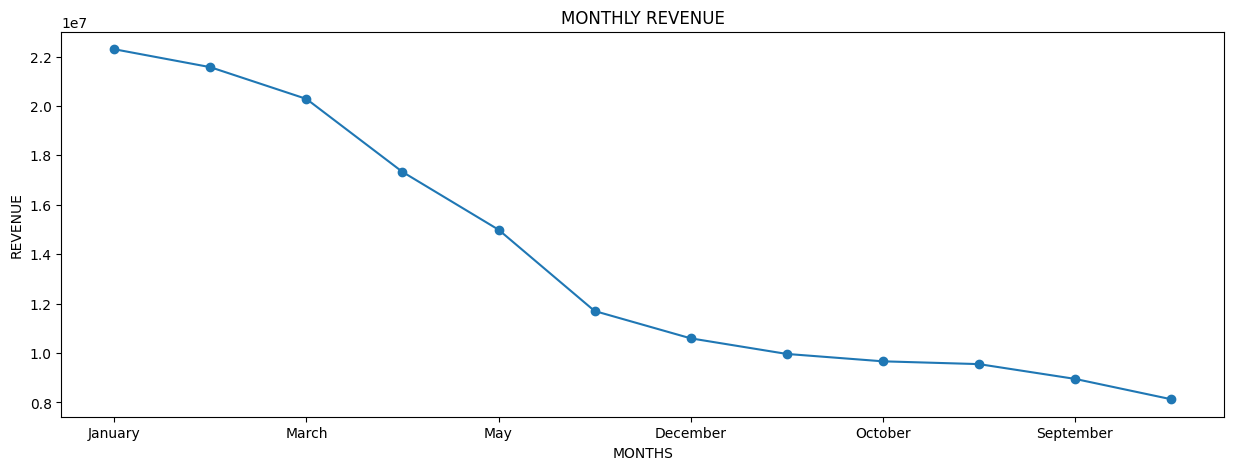

In [134]:
## monthly revenue
plt.figure(figsize=(15,5))
monthly_sales.sort_values(ascending=False).plot(kind='line',marker='o')
plt.title('MONTHLY REVENUE')
plt.xlabel('MONTHS')
plt.ylabel('REVENUE')

In [135]:
### top_product by revenue
top_product = df.groupby('product_name')['Amount'].sum().head(5).astype('int')
top_5_product=pd.DataFrame(top_product.sort_values(ascending=False))
top_5_product

,Amount
product_name,
Dell Inspiron,17443441
Laptop Bag,17389637
Lenovo IdeaPad,11479789
Keyboard,8818222
HP Pavilion,6206948


Text(0, 0.5, 'REVENUE')

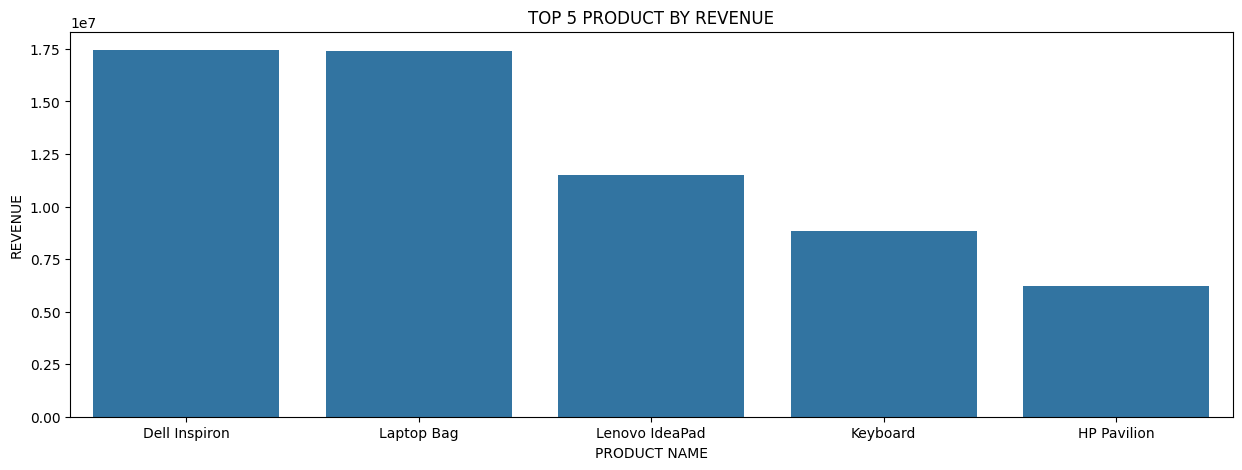

In [136]:
plt.figure(figsize=(15,5))
sns.barplot(x='product_name',y='Amount',data=top_5_product)
plt.title('TOP 5 PRODUCT BY REVENUE')
plt.xlabel('PRODUCT NAME')
plt.ylabel('REVENUE')

In [137]:
top_customer = df.groupby('customer_id')['Amount'].sum().head(5)
top_5_customer=pd.DataFrame(top_customer.sort_values(ascending=False))
top_5_customer

,Amount
customer_id,
C0001,1.089959e+06
C0005,8.904162e+05
C0003,5.452300e+05
C0002,4.940862e+05
C0004,6.099600e+04


Text(0, 0.5, 'REVENUE')

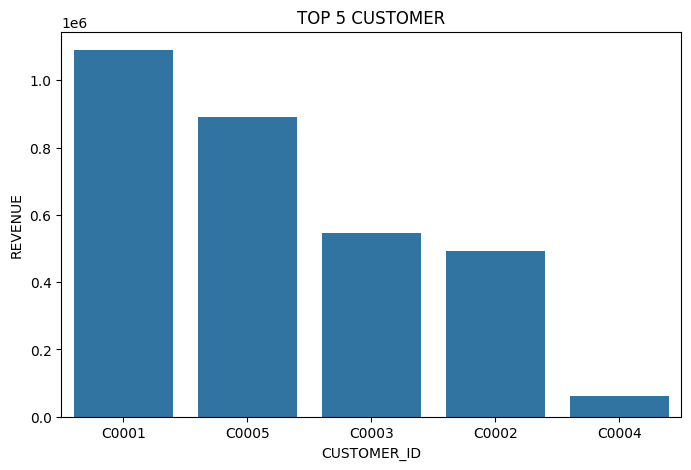

In [138]:
plt.figure(figsize=(8,5))
sns.barplot(x='customer_id',y='Amount',data=top_5_customer)
plt.title('TOP 5 CUSTOMER')
plt.xlabel('CUSTOMER_ID')
plt.ylabel('REVENUE')

In [144]:
df

,order_item_id,order_id,product_id,quantity,unit_price,product_name,category,base_price,customer_id,order_date,payment_method,customer_name,city,signup_date,Amount,month
0,1937.0,O00001,P025,1.0,84776.000000,Dell Inspiron,Laptop,84776.0,C0058,2024-09-05,Cash,Customer_58,Bengaluru,2024-02-13,84776.000000,September
1,844.0,O00001,P064,1.0,25696.000000,Lenovo IdeaPad,Accessories,81129.0,C0058,2024-09-05,Cash,Customer_58,Bengaluru,2024-02-13,25696.000000,September
2,892.0,O00002,P020,4.0,45038.245702,Dell Inspiron,Smartphone,NaN,C0410,2024-02-01,Upi,Customer_410,Delhi,2024-03-20,180152.982808,February
3,1293.0,O00002,P026,0.0,61323.000000,Xiaomi Redmi,Laptop,NaN,C0410,2024-02-01,Upi,Customer_410,Delhi,2024-03-20,0.000000,February
4,712.0,O00002,P075,1.0,45038.245702,iPhone 13,Smartphone,NaN,C0410,2024-02-01,Upi,Customer_410,Delhi,2024-03-20,45038.245702,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C0486,NaT,NaN,Customer_486,Chennai,2023-11-05,NaN,NaN
2288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C0487,NaT,NaN,Customer_487,Mumbai,2024-01-11,NaN,NaN
2289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C0491,NaT,NaN,Customer_491,Kolkata,2025-03-11,NaN,NaN
2290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C0499,NaT,NaN,Customer_499,Delhi,2023-01-13,NaN,NaN


In [145]:
# revenue by year
monthly_sales = df.groupby('month')['Amount'].sum().astype('int')
print(monthly_sales)

month
April        21569575
August        8129417
December     10593763
February     17330222
January      22296015
July          9962422
June         11699719
March        20284421
May          14990969
November      9550624
October       9663569
September     8952460
Name: Amount, dtype: int64


Text(0, 0.5, 'Revenue')

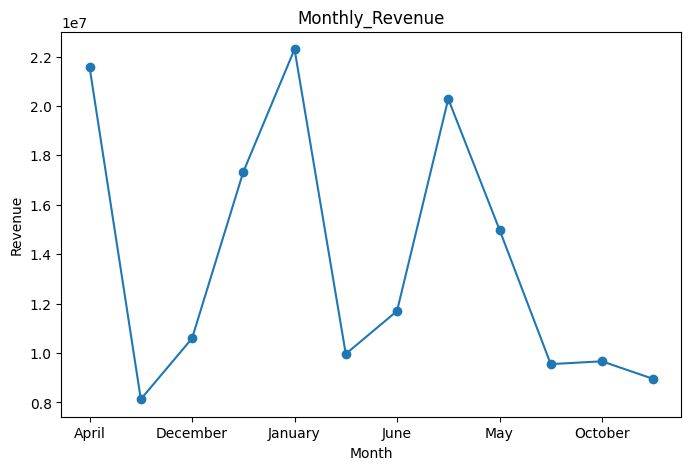

In [149]:
plt.figure(figsize=(8,5))
monthly_sales.plot(kind='line',marker='o')
plt.title('Monthly_Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')

In [150]:
citywise_sales = df.groupby('city')['Amount'].sum().astype('int')
city_sales = pd.DataFrame(citywise_sales.sort_values(ascending=False))
city_sales

,Amount
city,
Delhi,49714139
Mumbai,27276319
Hyderabad,23631820
Pune,17009852
Kolkata,12845589
Bangaluru,12317932
Bengaluru,11241891
Chennai,10985636


Text(0, 0.5, 'REVENUE')

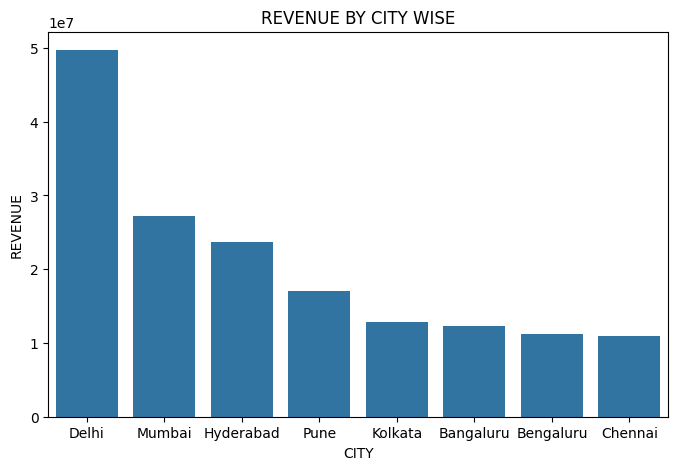

In [151]:
plt.figure(figsize=(8,5))
sns.barplot(x='city',y='Amount',data=city_sales)
plt.title('REVENUE BY CITY WISE')
plt.xlabel('CITY')
plt.ylabel('REVENUE')

In [152]:
category_revenue = df.groupby('category')['Amount'].sum().astype('int')
category_wise_revenue = pd.DataFrame(category_revenue.sort_values(ascending=False))
category_wise_revenue

,Amount
category,
Smartphone,53880121
Accessories,41561243
Tablet,38008154
Laptop,31573661


Text(0.5, 1.0, 'CATEGORY WISE REVENUE')

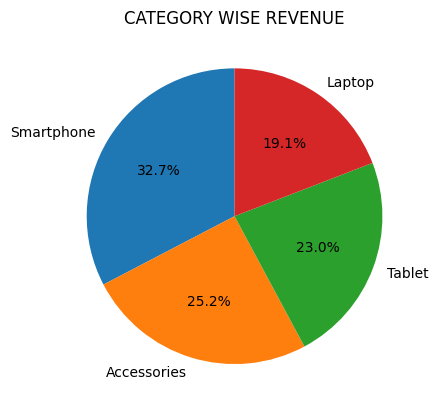

In [153]:
plt.pie(
    category_wise_revenue['Amount'],
    labels=category_wise_revenue.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('CATEGORY WISE REVENUE')

In [154]:
payment_methods = df.groupby('payment_method')['Amount'].sum().astype('int')
payment_wise_revenue = pd.DataFrame(payment_methods.sort_values(ascending=False))
payment_wise_revenue

,Amount
payment_method,
Cash,49578475
Upi,47240103
Credit Card,46314821
Debit Card,21889780


Text(0.5, 1.0, 'PAYMENT METHOD DISTRIBUTION')

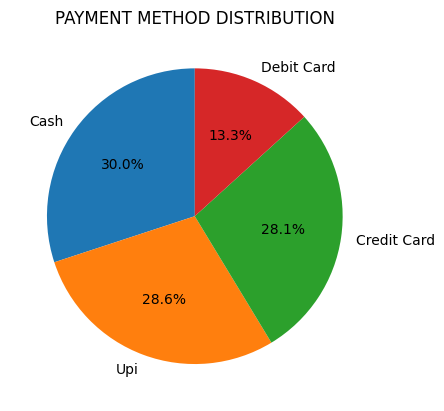

In [155]:
plt.pie(
    payment_wise_revenue['Amount'],
    labels=payment_wise_revenue.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('PAYMENT METHOD DISTRIBUTION')

In [156]:
monthly_qty_sold = df.groupby('month')['quantity'].sum()
print(monthly_qty_sold.sort_values(ascending=False))

month
January      495.0
April        488.0
March        427.0
February     387.0
May          349.0
December     250.0
June         249.0
July         231.0
November     219.0
October      211.0
September    193.0
August       186.0
Name: quantity, dtype: float64


Text(0, 0.5, 'QUANTITY')

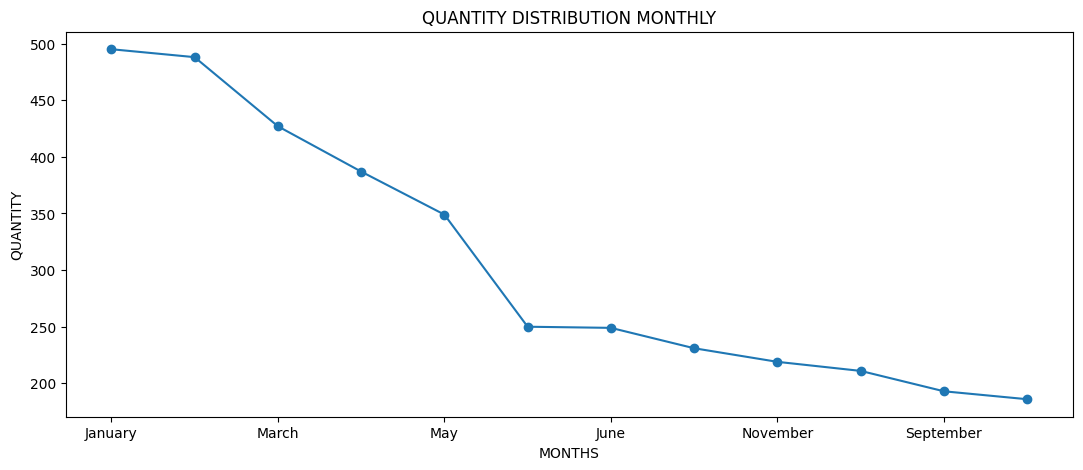

In [157]:
plt.figure(figsize=(13,5))
monthly_qty_sold.sort_values(ascending=False).plot(kind='line',marker='o')
plt.title('QUANTITY DISTRIBUTION MONTHLY')
plt.xlabel('MONTHS')
plt.ylabel('QUANTITY')

In [158]:
citywise_qty = df.groupby('city')['quantity'].sum()
city_qty = pd.DataFrame(citywise_qty.sort_values(ascending=False))
city_qty

,quantity
city,
Delhi,1100.0
Mumbai,638.0
Hyderabad,512.0
Pune,376.0
Bangaluru,283.0
Kolkata,277.0
Bengaluru,267.0
Chennai,232.0


Text(0, 0.5, 'QUANTITY')

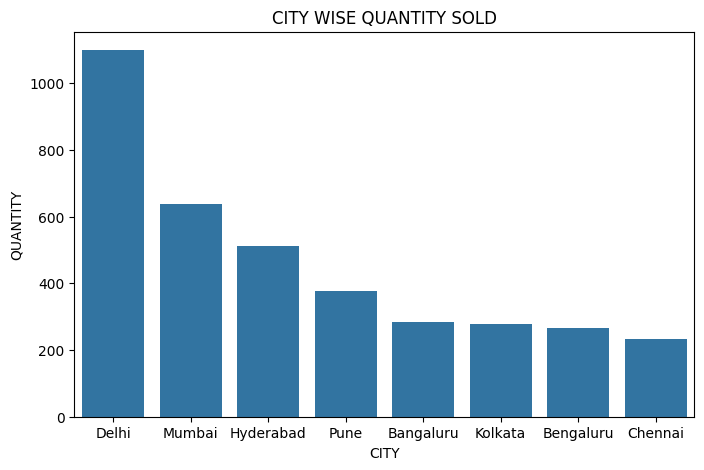

In [159]:
plt.figure(figsize=(8,5))
sns.barplot(x='city',y='quantity',data=city_qty)
plt.title('CITY WISE QUANTITY SOLD')
plt.xlabel('CITY')
plt.ylabel('QUANTITY')

In [160]:
top_product_sold =df.groupby('product_name')['quantity'].sum().head(5)
top_5_product=pd.DataFrame(top_product_sold.sort_values(ascending=False))
top_5_product

,quantity
product_name,
Dell Inspiron,361.0
Laptop Bag,354.0
Lenovo IdeaPad,262.0
Keyboard,205.0
HP Pavilion,137.0


Text(0, 0.5, 'QUANTITY')

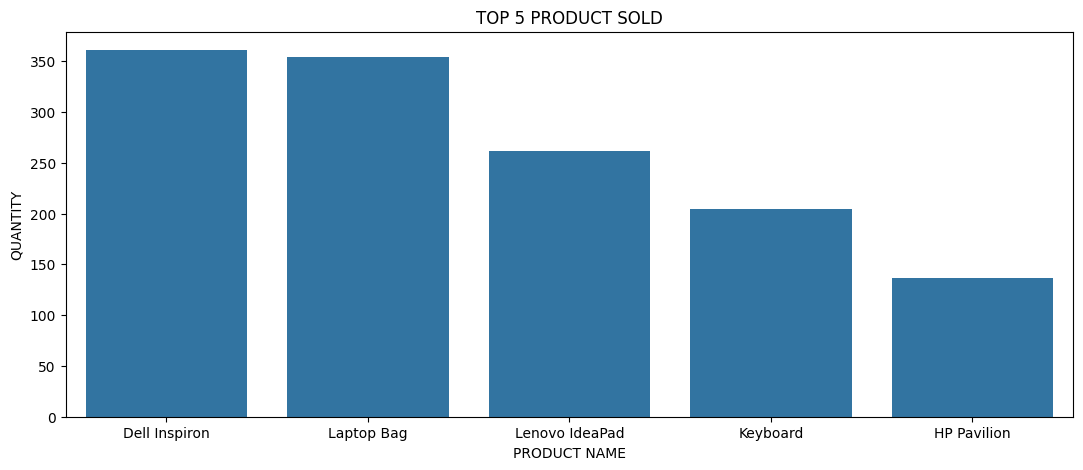

In [161]:
plt.figure(figsize=(13,5))
sns.barplot(x='product_name',y='quantity',data=top_5_product)
plt.title('TOP 5 PRODUCT SOLD')
plt.xlabel('PRODUCT NAME')
plt.ylabel('QUANTITY')

In [162]:
pay_methods = df.groupby('payment_method')['quantity'].sum()
pay = pd.DataFrame(pay_methods.sort_values(ascending=False))
pay

,quantity
payment_method,
Cash,1083.0
Credit Card,1066.0
Upi,1035.0
Debit Card,501.0


Text(0.5, 1.0, 'PAYMENT METHOD DISTRIBUTION')

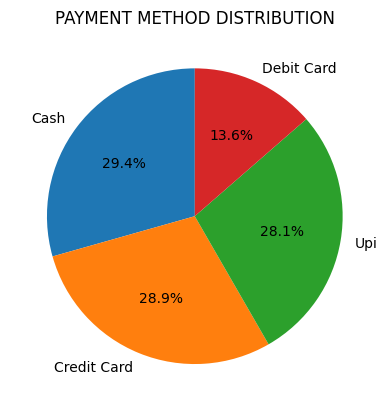

In [163]:
plt.pie(
    pay['quantity'],        #values
    labels=pay.index,       #category name
    autopct='%1.1f%%',      #shown the percentage
    startangle=90
)
plt.title('PAYMENT METHOD DISTRIBUTION')

In [164]:
category_qty = df.groupby('category')['quantity'].sum()
category_wise_qty = pd.DataFrame(category_qty.sort_values(ascending=False))
category_wise_qty 

,quantity
category,
Smartphone,1187.0
Accessories,938.0
Tablet,852.0
Laptop,708.0


Text(0.5, 1.0, 'CATEGORY WISE QUANTITY SOLD')

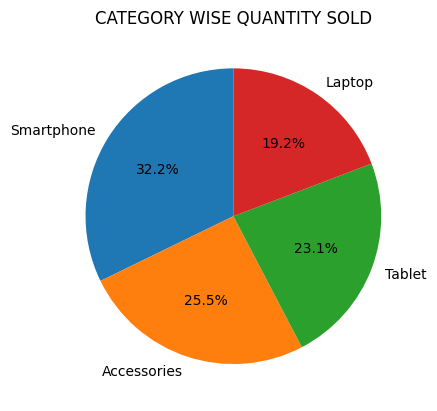

In [165]:
plt.pie(
    category_wise_qty['quantity'],      #VALUES
    labels=category_wise_qty.index,     #CATEGORY NAME
    autopct='%1.1f%%',                   #SHOWN THE PERCENTAGE
    startangle=90
)
plt.title('CATEGORY WISE QUANTITY SOLD')

In [166]:
top_cust = df.groupby('customer_id')['quantity'].sum().head(5)
top_5_customer = pd.DataFrame(top_cust.sort_values(ascending=False))
top_5_customer

,quantity
customer_id,
C0001,21.0
C0005,20.0
C0003,11.0
C0002,9.0
C0004,4.0


Text(0, 0.5, 'QUANTITY')

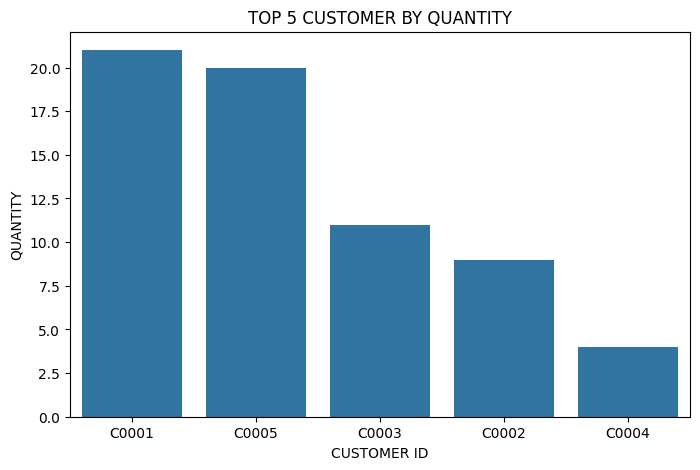

In [167]:
plt.figure(figsize=(8,5))
sns.barplot(x='customer_id',y='quantity',data=top_5_customer)
plt.title('TOP 5 CUSTOMER BY QUANTITY')
plt.xlabel('CUSTOMER ID')
plt.ylabel('QUANTITY')

Text(0.5, 1.0, 'Correlation')

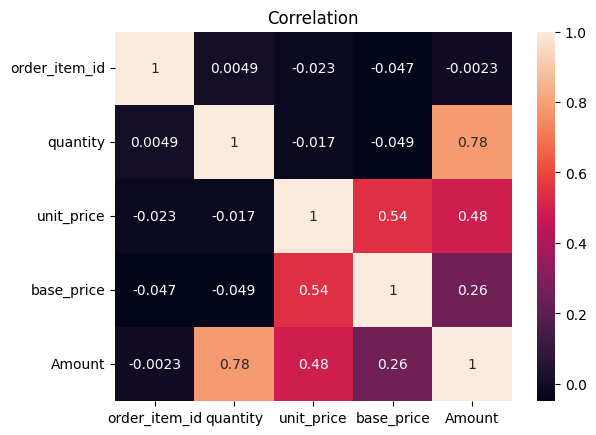

In [168]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(),annot=True)
plt.title('Correlation')

## 8 Final insights